In [7]:
import pandas as pd

SCMP_PATH = '../ln_tests/snippets_scmp.xlsx'
scmp = pd.read_excel(SCMP_PATH)
print(f'SCMP snippets : {len(scmp)}')
print(f'Distinct articles : {scmp["article_id"].nunique()}')
print(f'Columns           : {list(scmp.columns)}')
scmp.head(3)


SCMP snippets : 1559
Distinct articles : 62
Columns           : ['article_id', 'title', 'outlet', 'date', 'snippet', 'word_count', 'china', 'indonesia', 'nickel']


,article_id,title,outlet,date,snippet,word_count,china,indonesia,nickel
0,urn:contentItem:60HT-VXT1-JC8V-135X-00000-00,Protesting Indonesian students write to Chines...,"South China Morning Post.com, EDT, 1037words",2020-08-06,Protesting Indonesian students write to Chines...,120,1,1,1
1,urn:contentItem:60HT-VXT1-JC8V-135X-00000-00,Protesting Indonesian students write to Chines...,"South China Morning Post.com, EDT, 1037words",2020-08-06,"Since March, the students have been holding de...",62,0,0,1
2,urn:contentItem:60HT-VXT1-JC8V-135X-00000-00,Protesting Indonesian students write to Chines...,"South China Morning Post.com, EDT, 1037words",2020-08-06,The protesters say the Chinese arrivals are no...,63,1,0,0


In [8]:
# below is prepared in NB1 

import json as _json

NER_PATH = 'ner_actor_codebook.json'
with open(NER_PATH, 'r', encoding='utf-8') as f:
    ner_records = _json.load(f)

print(f'Actor categories loaded: {len(ner_records)}')
for rec in ner_records:
    print(f"  {rec['actor_label']}: {len(rec['named_entities'])} entities, {len(rec['trigger_phrases'])} trigger phrases")


Actor categories loaded: 13
  Chinese DFIs (banks): 8 entities, 15 trigger phrases
  Chinese firms/SOEs: 19 entities, 15 trigger phrases
  Chinese government: 7 entities, 7 trigger phrases
  Chinese worker: 12 entities, 6 trigger phrases
  Indonesian government: central government/president: 13 entities, 8 trigger phrases
  Indonesian government: local government (provincial/regional officials): 12 entities, 6 trigger phrases
  Indonesian firms and local elites: 19 entities, 7 trigger phrases
  Indonesian local civil society: 18 entities, 8 trigger phrases
  Indonesian local community & workers: 17 entities, 3 trigger phrases
  International governmental and intergovernmental actors: 22 entities, 10 trigger phrases
  International companies: 38 entities, 12 trigger phrases
  International NGOs/watchdog: 9 entities, 5 trigger phrases
  *Others: 4 entities, 0 trigger phrases


In [9]:
def _expand_terms(terms):
    """
    Parse codebook entries where:
      - ';'  separates distinct entities     → each becomes its own entry
      - ' OR ' separates alternative spellings of the same entity → each kept as its own entry
    Works on a list of raw strings (as stored in the JSON).
    """
    expanded = []
    for raw in terms:
        for segment in str(raw).split(';'):
            segment = segment.strip()
            if not segment:
                continue
            for alt in segment.split(' OR '):
                alt = alt.strip()
                if alt:
                    expanded.append(alt)
    return expanded

# Apply in-place so all downstream functions see the expanded lists
for rec in ner_records:
    rec['named_entities']  = _expand_terms(rec['named_entities'])
    rec['trigger_phrases'] = _expand_terms(rec['trigger_phrases'])

print('After expansion:')
for rec in ner_records:
    print(f"  {rec['actor_label']}: {len(rec['named_entities'])} entities, {len(rec['trigger_phrases'])} trigger phrases")


After expansion:
  Chinese DFIs (banks): 8 entities, 15 trigger phrases
  Chinese firms/SOEs: 20 entities, 15 trigger phrases
  Chinese government: 9 entities, 7 trigger phrases
  Chinese worker: 12 entities, 6 trigger phrases
  Indonesian government: central government/president: 15 entities, 8 trigger phrases
  Indonesian government: local government (provincial/regional officials): 12 entities, 6 trigger phrases
  Indonesian firms and local elites: 25 entities, 7 trigger phrases
  Indonesian local civil society: 23 entities, 8 trigger phrases
  Indonesian local community & workers: 18 entities, 3 trigger phrases
  International governmental and intergovernmental actors: 30 entities, 10 trigger phrases
  International companies: 38 entities, 12 trigger phrases
  International NGOs/watchdog: 9 entities, 5 trigger phrases
  *Others: 4 entities, 0 trigger phrases


In [10]:
import re
from collections import defaultdict

def make_pattern(term):
    """Build a regex pattern that matches term and its common plural/suffix forms."""
    t = term.lower()
    if t.endswith('y') and len(t) > 2 and t[-2] not in 'aeiou':
        core = re.escape(t[:-1])
        return r'\b' + core + r'(?:y|ies)\b'
    elif re.search(r'(?:s|x|ch|sh|z)$', t):
        return r'\b' + re.escape(t) + r'(?:es)?\b'
    else:
        return r'\b' + re.escape(t) + r's?\b'

CONTEXT_ONLY = {'market', 'environment'}

def extract_named_entities(text):
    """Match named entities, grouping same-label matches: 'Name1; Name2 (Category)'."""
    hits = defaultdict(list)
    text_lower = str(text).lower()
    for rec in ner_records:
        label = rec['actor_label']
        for ent in rec['named_entities']:
            if ent.lower() in CONTEXT_ONLY:
                continue
            if re.search(make_pattern(ent), text_lower):
                hits[label].append(ent)
    parts = [f"{'; '.join(names)} ({label})" for label, names in hits.items()]
    return '; '.join(parts) if parts else ''

def extract_trigger_signals(text):
    """Match trigger phrases -> '"phrase" -> Category' format."""
    found = []
    text_lower = str(text).lower()
    seen = set()
    for rec in ner_records:
        label = rec['actor_label']
        for phrase in rec['trigger_phrases']:
            if re.search(make_pattern(phrase), text_lower):
                entry = f'"{phrase}" -> {label}'
                if entry not in seen:
                    seen.add(entry)
                    found.append(entry)
    return '; '.join(found) if found else ''

def extract_context_words(text, keywords=('market', 'environment')):
    """For each keyword found, capture the word before and after it as context."""
    words = re.findall(r'\b\w+\b', str(text).lower())
    found = []
    for i, word in enumerate(words):
        if word in keywords:
            before = words[i - 1] if i > 0 else ''
            after  = words[i + 1] if i < len(words) - 1 else ''
            context = ' '.join(filter(None, [before, word, after]))
            found.append(f'{context} [context]')
    return '; '.join(found) if found else ''

scmp = scmp.copy()
scmp['actors_mentioned'] = scmp['snippet'].apply(extract_named_entities)
scmp['actor_signals']    = scmp['snippet'].apply(extract_trigger_signals)
scmp['_context_words']   = scmp['snippet'].apply(extract_context_words)

n_ent  = (scmp['actors_mentioned'] != '').sum()
n_sig  = (scmp['actor_signals']    != '').sum()
n_both = ((scmp['actors_mentioned'] != '') & (scmp['actor_signals'] != '')).sum()
print(f'Snippets matched by named entity    : {n_ent} / {len(scmp)} ({n_ent/len(scmp)*100:.1f}%)')
print(f'Snippets matched by trigger phrase  : {n_sig} / {len(scmp)} ({n_sig/len(scmp)*100:.1f}%)')
print(f'Snippets matched by both            : {n_both}')
scmp[scmp['actors_mentioned'] != ''][['snippet','actors_mentioned','actor_signals']].head(3)

Snippets matched by named entity    : 827 / 1559 (53.0%)
Snippets matched by trigger phrase  : 354 / 1559 (22.7%)
Snippets matched by both            : 226


,snippet,actors_mentioned,actor_signals
0,Protesting Indonesian students write to Chines...,Chinese workers; Chinese nationals (Chinese wo...,"""locals"" -> Indonesian local community & workers"
1,"Since March, the students have been holding de...",Chinese workers (Chinese worker); residents (I...,"""regency"" -> Indonesian government: local gove..."
2,The protesters say the Chinese arrivals are no...,residents (Indonesian local community & workers),


In [11]:
# ── Plural matching sanity check ─────────────────────────────────────────────
import re

# pairs: (term from codebook, plural form that must also match)
TEST_CASES = [
    # y → ies
    ('community',    'communities'),
    ('company',      'companies'),
    ('authority',    'authorities'),
    ('ministry',     'ministries'),
    # default s
    ('government',   'governments'),
    ('worker',       'workers'),
    ('investor',     'investors'),
    ('activist',     'activists'),
    ('contractor',   'contractors'),
    ('organization', 'organizations'),
    # singular still matches
    ('government',   'government'),
    ('community',    'community'),
    # named entities — plural should not break match
    ('Tesla',        'Tesla'),
    ('Greenpeace',   'Greenpeace'),
]

print(f'{"Term":<20} {"Test string":<20} {"Pattern":<35} {"Match"}')
print('-' * 85)
all_pass = True
for term, test_str in TEST_CASES:
    pattern = make_pattern(term)
    match   = bool(re.search(pattern, test_str.lower()))
    status  = 'PASS' if match else 'FAIL'
    if not match: all_pass = False
    print(f'{term:<20} {test_str:<20} {pattern:<35} {status}')

print()
print('All tests passed.' if all_pass else 'Some tests FAILED — review make_pattern().')

# also spot-check against real trigger phrases from the codebook
print('\n--- Live codebook terms ---')
sample_phrases = [(rec['actor_label'], p)
                  for rec in ner_records
                  for p in rec['trigger_phrases'][:2]]
test_sentences = [
    'local governments have issued permits',
    'mining communities were displaced',
    'Chinese companies and investors',
    'provincial authorities cracked down',
    'construction workers from China',
]
for sentence in test_sentences:
    hits = []
    for rec in ner_records:
        for p in rec['trigger_phrases']:
            if re.search(make_pattern(p), sentence.lower()):
                hits.append(f'{p} ({rec["actor_label"]})')
    print(f'  "{sentence}"')
    print(f'    -> {hits if hits else "no match"}')


Term                 Test string          Pattern                             Match
-------------------------------------------------------------------------------------
community            communities          \bcommunit(?:y|ies)\b               PASS
company              companies            \bcompan(?:y|ies)\b                 PASS
authority            authorities          \bauthorit(?:y|ies)\b               PASS
ministry             ministries           \bministr(?:y|ies)\b                PASS
government           governments          \bgovernments?\b                    PASS
worker               workers              \bworkers?\b                        PASS
investor             investors            \binvestors?\b                      PASS
activist             activists            \bactivists?\b                      PASS
contractor           contractors          \bcontractors?\b                    PASS
organization         organizations        \borganizations?\b                  PASS


In [12]:
# ── OR-group and Jakarta sanity checks ───────────────────────────────────────

# 1. All OR-alternatives for the same conceptual entity are individually found
OR_ALTS = ['Xi Jinping', 'President Xi', 'Beijing']
print('=== OR-alternative matching (each must be found) ===')
all_found = True
for alt in OR_ALTS:
    pattern = make_pattern(alt)
    matched = bool(re.search(pattern, alt.lower()))
    status  = 'PASS' if matched else 'FAIL'
    if not matched: all_found = False
    print(f'  {alt:<20} matched: {status}')

# 2. When all three appear in the same text, they resolve to exactly 1 unique actor label
test_sentence = 'Xi Jinping met with President Xi aides while Beijing issued a statement.'
hits = []
for rec in ner_records:
    for ent in rec['named_entities']:
        if re.search(make_pattern(ent), test_sentence.lower()):
            hits.append((ent, rec['actor_label']))

unique_labels = set(label for _, label in hits if any(a.lower() in ent.lower() for a in OR_ALTS
                                                        for ent, _ in hits))
# simpler: collect labels only for the OR alternatives
or_labels = set(label for ent, label in hits if ent in OR_ALTS)
n_unique   = len(or_labels)
status_or  = 'PASS' if n_unique == 1 else 'FAIL'
print(f'\n=== OR-group → 1 actor label ===')
print(f'  Matched alternatives : {[e for e, _ in hits if e in OR_ALTS]}')
print(f'  Unique actor labels  : {or_labels}  →  {status_or} (expected 1)')

# 3. "Jakarta" appears in actors_mentioned
print(f'\n=== "Jakarta" in actors_mentioned ===')
jakarta_hits = scmp[scmp['actors_mentioned'].str.contains('Jakarta', case=False, na=False)]
status_jak   = 'PASS' if len(jakarta_hits) > 0 else 'FAIL — Jakarta not found in actors_mentioned'
print(f'  Snippets with Jakarta in actors_mentioned: {len(jakarta_hits)}  →  {status_jak}')
if len(jakarta_hits) > 0:
    print(f'  Example: {jakarta_hits["actors_mentioned"].iloc[0][:120]}')


=== OR-alternative matching (each must be found) ===
  Xi Jinping           matched: PASS
  President Xi         matched: PASS
  Beijing              matched: PASS

=== OR-group → 1 actor label ===
  Matched alternatives : ['Xi Jinping', 'President Xi', 'Beijing']
  Unique actor labels  : {'Chinese government'}  →  PASS (expected 1)

=== "Jakarta" in actors_mentioned ===
  Snippets with Jakarta in actors_mentioned: 164  →  PASS
  Example: Chinese workers; Chinese nationals (Chinese worker); Jakarta (Indonesian government: central government/president); resi


In [13]:
from collections import Counter

def parse_actors(cell):
    """Parse 'Name1; Name2 (label); Name3 (label2)' into (name, label) tuples."""
    items = []
    for group in re.findall(r'([\w\s;,\-\'\.]+?)\s*\(([^)]+)\)', cell):
        names_str, label = group
        for name in names_str.split(';'):
            name = name.strip()
            if name:
                items.append((name, label))
    return items

# ── named entity frequency ───────────────────────────────────────────────────
cat_counts    = Counter()
entity_counts = Counter()
for cell in scmp['actors_mentioned']:
    if not cell:
        continue
    for name, label in parse_actors(cell):
        entity_counts[f'{name} ({label})'] += 1
        cat_counts[label] += 1

# ── trigger phrase frequency ─────────────────────────────────────────────────
sig_cat_counts    = Counter()
sig_phrase_counts = Counter()
for cell in scmp['actor_signals']:
    if not cell:
        continue
    for match in cell.split('; '):
        match = match.strip()
        if not match:
            continue
        sig_phrase_counts[match] += 1
        m = re.search(r'->\s*(.+)$', match)
        if m:
            sig_cat_counts[m.group(1).strip()] += 1

# ── combined category table ──────────────────────────────────────────────────
all_cats = set(cat_counts) | set(sig_cat_counts)
combined = pd.DataFrame([
    {'actor_category'   : c,
     'entity_mentions'  : cat_counts.get(c, 0),
     'trigger_mentions' : sig_cat_counts.get(c, 0)}
    for c in all_cats
]).sort_values('entity_mentions', ascending=False).reset_index(drop=True)
combined['total'] = combined['entity_mentions'] + combined['trigger_mentions']
combined = combined.sort_values('total', ascending=False).reset_index(drop=True)

print('=== Mentions per actor category ===')
print(combined.to_string(index=False))

# ── top entities + top trigger phrases ───────────────────────────────────────
ent_df = (pd.DataFrame.from_dict(entity_counts, orient='index', columns=['mentions'])
            .sort_values('mentions', ascending=False).head(20)
            .reset_index().rename(columns={'index': 'entity'}))
sig_df = (pd.DataFrame.from_dict(sig_phrase_counts, orient='index', columns=['mentions'])
            .sort_values('mentions', ascending=False).head(20)
            .reset_index().rename(columns={'index': 'trigger_signal'}))

print('\n=== Top 20 named entity mentions ===')
print(ent_df.to_string(index=False))
print('\n=== Top 20 trigger phrase signals ===')
print(sig_df.to_string(index=False))

# save top 100 snippets — drop internal helper columns before writing
scmp['n_entity_mentions'] = scmp['actors_mentioned'].apply(
    lambda x: len(parse_actors(x)) if x else 0
)
top100 = scmp.nlargest(100, 'n_entity_mentions')

SCMP_OUT = r'C:\Users\charlott\Dropbox (Personal)\Paper_Indonesia_Nickel\ln_tests\100_snippets_scmp_NER.xlsx'
top100.drop(columns=['_context_words'], errors='ignore').to_excel(SCMP_OUT, index=False)
print(f'Top 100 snippets by entity mentions saved: {SCMP_OUT}')
print(f'Entity mention counts range: {top100["n_entity_mentions"].min()} – {top100["n_entity_mentions"].max()}')

=== Mentions per actor category ===
                                                         actor_category  entity_mentions  trigger_mentions  total
                    Indonesian government: central government/president              551                28    579
                International governmental and intergovernmental actors              318                 9    327
                                                     Chinese firms/SOEs              104               152    256
                                                International companies              143                39    182
                                                     Chinese government              101                44    145
                                         Indonesian local civil society               20                72     92
                                      Indonesian firms and local elites               42                18     60
                                                    

In [14]:
# ── Codebook expansion candidates ────────────────────────────────────────────
# For each snippet where actor_signals fires for a category that has NO match
# in actors_mentioned, show the surrounding sentence context around the trigger phrase.
# Context words (market / environment) are appended here rather than in actors_mentioned.
# Output column 'candidate_entities' is for manual review / codebook expansion.

def extract_gap_candidates(row):
    snippet  = str(row['snippet'])
    signals  = str(row['actor_signals'])
    mentions = str(row['actors_mentioned'])

    if not signals or signals == 'nan':
        return ''

    # Categories already covered by named-entity matching
    mentioned_cats = set(re.findall(r'\(([^)]+)\)', mentions))

    # Trigger phrases and their signaled categories
    signal_pairs = re.findall(r'"([^"]+)"\s*->\s*([^;]+)', signals)

    # Keep only pairs where the category is NOT yet in actors_mentioned
    gap_pairs = [(phrase.strip(), cat.strip())
                 for phrase, cat in signal_pairs
                 if cat.strip() not in mentioned_cats]

    if not gap_pairs:
        return ''

    snippet_lower = snippet.lower()
    results = []

    for phrase, cat in gap_pairs:
        pos = snippet_lower.find(phrase.lower())
        if pos == -1:
            continue

        # ±80-char window around the trigger phrase
        start  = max(0, pos - 80)
        end    = min(len(snippet), pos + len(phrase) + 80)
        window = snippet[start:end].strip().replace('\n', ' ')

        prefix = '...' if start > 0          else ''
        suffix = '...' if end < len(snippet) else ''

        results.append(f'"{phrase}" → {prefix}{window}{suffix} [{cat}]')

    return ' | '.join(results) if results else ''


scmp['candidate_entities'] = scmp.apply(extract_gap_candidates, axis=1)

# Append context words into candidate_entities (not actors_mentioned)
scmp['candidate_entities'] = scmp.apply(
    lambda r: '; '.join(filter(None, [r['candidate_entities'], r['_context_words']])),
    axis=1
)

scmp['source'] = 'scmp'

n_candidates = (scmp['candidate_entities'] != '').sum()
print(f'SCMP snippets with expansion candidates : {n_candidates} / {len(scmp)}')

SCMP snippets with expansion candidates : 411 / 1559


In [15]:
# ── Asia Times NER extraction ────────────────────────────────────────────────
AT_PATH = '../ln_tests/snippets_asia_times.xlsx'
asia_times = pd.read_excel(AT_PATH)

asia_times = asia_times.copy()
asia_times['actors_mentioned'] = asia_times['snippet'].apply(extract_named_entities)
asia_times['actor_signals']    = asia_times['snippet'].apply(extract_trigger_signals)
asia_times['_context_words']   = asia_times['snippet'].apply(extract_context_words)

asia_times['n_entity_mentions'] = asia_times['actors_mentioned'].apply(
    lambda x: len(parse_actors(x)) if x else 0
)
top100_at = asia_times.nlargest(100, 'n_entity_mentions')

AT_OUT = '../ln_tests/100_snippets_asia_times_NER.xlsx'
top100_at.drop(columns=['_context_words'], errors='ignore').to_excel(AT_OUT, index=False)
print(f'Saved: {AT_OUT}')
print(f'Entity mention counts range: {top100_at["n_entity_mentions"].min()} – {top100_at["n_entity_mentions"].max()}')

asia_times['candidate_entities'] = asia_times.apply(extract_gap_candidates, axis=1)
asia_times['candidate_entities'] = asia_times.apply(
    lambda r: '; '.join(filter(None, [r['candidate_entities'], r['_context_words']])),
    axis=1
)
asia_times['source'] = 'asia times'

n_candidates_at = (asia_times['candidate_entities'] != '').sum()
print(f'Asia Times snippets with expansion candidates : {n_candidates_at} / {len(asia_times)}')

# ── Combine and deduplicate at 80% snippet similarity ────────────────────────
from difflib import SequenceMatcher

cols = ['source', 'snippet', 'actors_mentioned', 'actor_signals', 'candidate_entities']

combined = pd.concat([
    scmp[scmp['candidate_entities'] != ''][cols],
    asia_times[asia_times['candidate_entities'] != ''][cols]
], ignore_index=True)

print(f'\nCombined before deduplication : {len(combined)} rows')

def deduplicate(df, col='snippet', threshold=0.80):
    texts     = df[col].tolist()
    keep_mask = [True] * len(texts)
    for i in range(len(texts)):
        if not keep_mask[i]:
            continue
        for j in range(i + 1, len(texts)):
            if not keep_mask[j]:
                continue
            ratio = SequenceMatcher(None, texts[i], texts[j]).ratio()
            if ratio >= threshold:
                keep_mask[j] = False
    return df[keep_mask].reset_index(drop=True)

combined_dedup = deduplicate(combined)
print(f'Combined after deduplication  : {len(combined_dedup)} rows  '
      f'({len(combined) - len(combined_dedup)} removed)')

CANDIDATES_OUT = '../ln_tests/codebook_expansion_via_cues.xlsx'
(combined_dedup
    .sort_values('candidate_entities')
    .to_excel(CANDIDATES_OUT, index=False))
print(f'Saved to {CANDIDATES_OUT}')

Saved: ../ln_tests/100_snippets_asia_times_NER.xlsx
Entity mention counts range: 2 – 6
Asia Times snippets with expansion candidates : 156 / 867

Combined before deduplication : 567 rows
Combined after deduplication  : 548 rows  (19 removed)
Saved to ../ln_tests/codebook_expansion_via_cues.xlsx


Rationale for `codebook_expansion_via_cues.xlsx` (for manual review):

- **Gap detection**: compares categories in `actor_signals` against those already in `actors_mentioned` — only processes the difference, so you only see cases where a trigger phrase fired but no named entity was found for that category.
- **Context extraction**: for each gap trigger phrase, takes a ±80-char window of raw text around it in the snippet.
- **Output format**: `"BRI" → ...Indonesia's foreign policy and the BRI has been a driver of... [Chinese government]` — the trigger phrase, the surrounding sentence as written, and the category it signals. Use the context to decide whether a new named entity should be added to the codebook.

In [16]:
# ── Full-dataset entity frequency by category ─────────────────────────────────
import matplotlib.pyplot as plt
from collections import Counter

LN_PATH = '../ln_preprocessing/ln_data_final.csv'
ln_full = pd.read_csv(LN_PATH)
print(f'Full dataset: {len(ln_full):,} articles')

ln_full['actors_mentioned'] = ln_full['Text_body'].apply(extract_named_entities)

n_matched = (ln_full['actors_mentioned'] != '').sum()
print(f'Articles with at least one matched entity: {n_matched:,} / {len(ln_full):,} ({100*n_matched/len(ln_full):.1f}%)')


Full dataset: 2,334 articles
Articles with at least one matched entity: 2,128 / 2,334 (91.2%)



=== Entity mentions by category (full dataset) ===
                                                              category  mentions
               International governmental and intergovernmental actors      3387
                                               International companies      1962
                   Indonesian government: central government/president      1810
                                                    Chinese firms/SOEs       913
                                                    Chinese government       716
                                     Indonesian firms and local elites       463
                                                               *Others       291
                                  Indonesian local community & workers       282
                                                        Chinese worker       130
                                           International NGOs/watchdog        68
                                        Indonesian local 

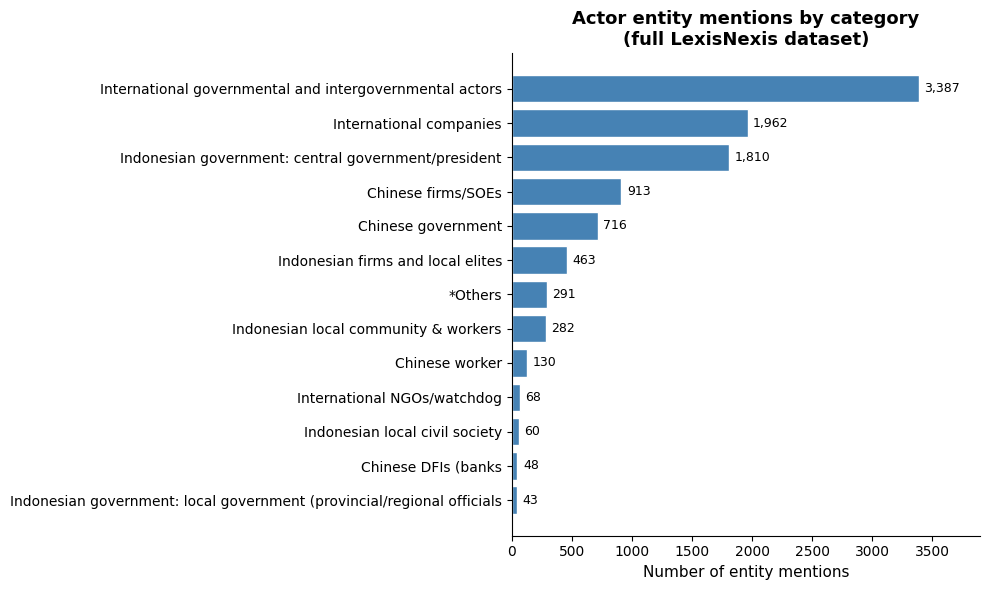

Figure saved: entity_mentions_by_category.png


In [17]:

# Count mentions per category
cat_counts = Counter()
for cell in ln_full['actors_mentioned']:
    if not cell:
        continue
    for _, label in parse_actors(cell):
        cat_counts[label] += 1

cat_df = (pd.DataFrame.from_dict(cat_counts, orient='index', columns=['mentions'])
            .sort_values('mentions', ascending=True)
            .reset_index().rename(columns={'index': 'category'}))

print('\n=== Entity mentions by category (full dataset) ===')
print(cat_df.sort_values('mentions', ascending=False).to_string(index=False))

# ── Figure ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(cat_df['category'], cat_df['mentions'], color='steelblue', edgecolor='white')
ax.bar_label(bars, fmt='{:,.0f}', padding=4, fontsize=9)
ax.set_xlabel('Number of entity mentions', fontsize=11)
ax.set_title('Actor entity mentions by category\n(full LexisNexis dataset)', fontsize=13, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.margins(x=0.15)
plt.tight_layout()

FIG_OUT = 'entity_mentions_by_category.png'
plt.savefig(FIG_OUT, dpi=150, bbox_inches='tight')
plt.show()
print(f'Figure saved: {FIG_OUT}')

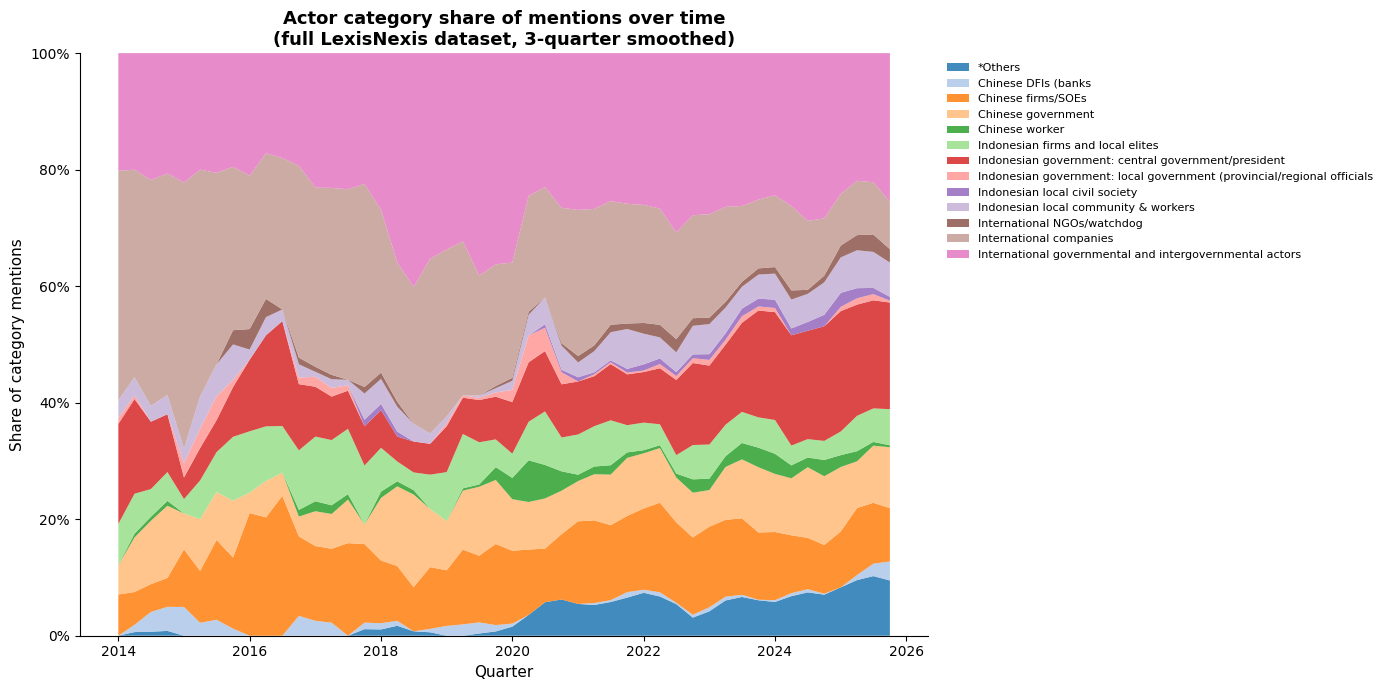

Figure saved: entity_categories_over_time.png


In [18]:
# ── Actor categories over time — normalised stacked area (smoothed) ───────────
# Reuses ln_full with actors_mentioned already computed above.

ln_full['date_parsed'] = pd.to_datetime(ln_full['Date'], errors='coerce')
ln_full['quarter']     = ln_full['date_parsed'].dt.to_period('Q')

# One row per (article, category) — each category counted once per article
records = []
for _, row in ln_full.iterrows():
    if not row['actors_mentioned']:
        continue
    q = row['quarter']
    if pd.isna(q):
        continue
    seen_cats = set()
    for _, label in parse_actors(row['actors_mentioned']):
        if label not in seen_cats:
            records.append({'quarter': q, 'category': label})
            seen_cats.add(label)

time_df = pd.DataFrame(records)
pivot   = (time_df.groupby(['quarter', 'category'])
                  .size()
                  .unstack(fill_value=0)
                  .sort_index())

# Smooth with 3-quarter rolling mean, then normalise rows to sum to 1
smoothed = pivot.rolling(window=3, min_periods=1, center=True).mean()
normed   = smoothed.div(smoothed.sum(axis=1), axis=0)
normed.index = normed.index.to_timestamp()

# ── Figure ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 7))

colors = plt.cm.tab20.colors[:len(normed.columns)]
ax.stackplot(normed.index,
             [normed[col] for col in normed.columns],
             labels=normed.columns,
             colors=colors,
             alpha=0.85)

ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.set_xlabel('Quarter', fontsize=11)
ax.set_ylabel('Share of category mentions', fontsize=11)
ax.set_title('Actor category share of mentions over time\n(full LexisNexis dataset, 3-quarter smoothed)', fontsize=13, fontweight='bold')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8, frameon=False)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()

FIG_TIME = 'entity_categories_over_time.png'
plt.savefig(FIG_TIME, dpi=150, bbox_inches='tight')
plt.show()
print(f'Figure saved: {FIG_TIME}')

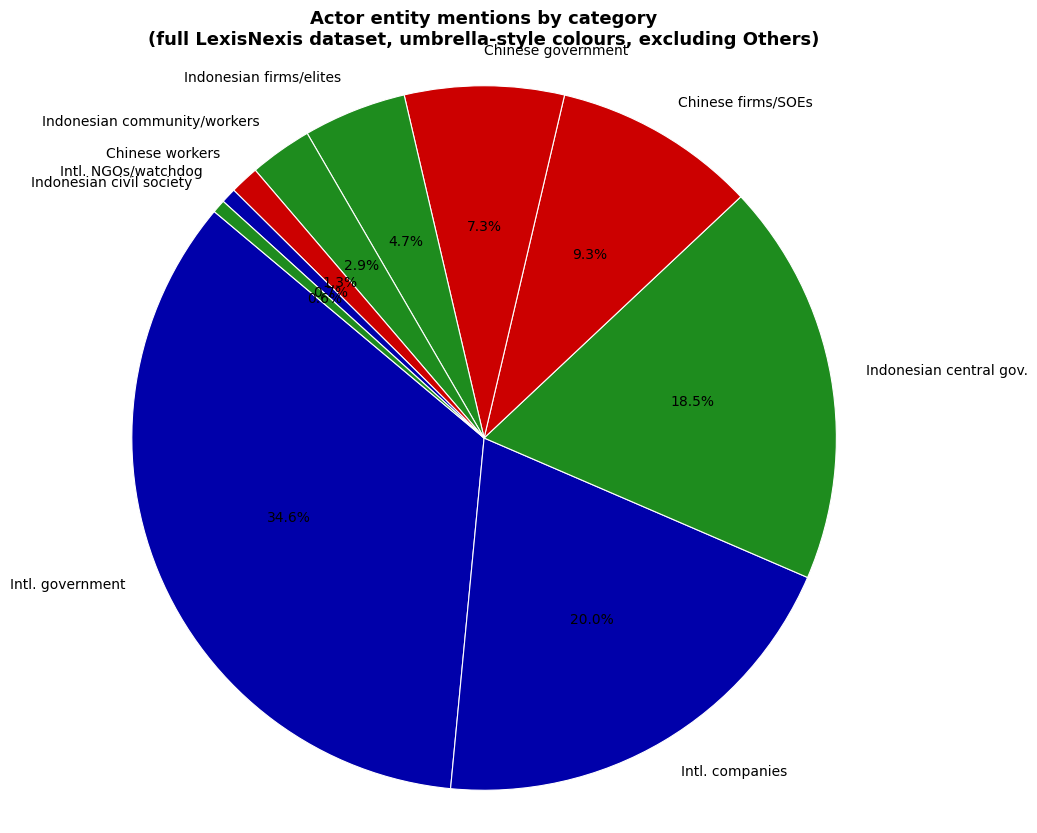

Figure saved: entity_mentions_by_category_umbrella_colors.png


In [19]:
# ── Umbrella categories over time — normalised stacked area (smoothed) ────────

UMBRELLA = {
    'Chinese DFIs (banks)':                                                      ('Chinese',       0),
    'Chinese firms/SOEs':                                                        ('Chinese',       1),
    'Chinese government':                                                        ('Chinese',       2),
    'Chinese worker':                                                            ('Chinese',       3),
    'Indonesian government: central government/president':                       ('Indonesian',    0),
    'Indonesian government: local government (provincial/regional officials)':   ('Indonesian',    1),
    'Indonesian firms and local elites':                                         ('Indonesian',    2),
    'Indonesian local civil society':                                            ('Indonesian',    3),
    'Indonesian local community & workers':                                      ('Indonesian',    4),
    'International governmental and intergovernmental actors':                                   ('International', 0),
    'International companies':                                                   ('International', 1),
    'International NGOs/watchdog':                                               ('International', 2),
}

SHADES = {
    'Chinese':       ['#FFAAAA', '#FF5555', '#CC0000', '#7A0000'],
    'Indonesian':    ['#AAF0AA', '#55CC55', '#1E8C1E', '#0A5C0A', '#072E07'],
    'International': ['#AAAAFF', '#5555CC', '#0000AA'],
}

SHORT_LABELS = {
    'Chinese DFIs (banks)':                                                      'Chinese DFIs',
    'Chinese firms/SOEs':                                                        'Chinese firms/SOEs',
    'Chinese government':                                                        'Chinese government',
    'Chinese worker':                                                            'Chinese workers',
    'Indonesian government: central government/president':                       'Indonesian central gov.',
    'Indonesian government: local government (provincial/regional officials)':   'Indonesian local gov.',
    'Indonesian firms and local elites':                                         'Indonesian firms/elites',
    'Indonesian local civil society':                                            'Indonesian civil society',
    'Indonesian local community & workers':                                      'Indonesian community/workers',
    'International governmental and intergovernmental actors':                                   'Intl. government',
    'International companies':                                                   'Intl. companies',
    'International NGOs/watchdog':                                               'Intl. NGOs/watchdog',
}

# ── Actor mentions by category — pie chart with umbrella-style colours ─────────
umbrella_group_map = {
    'Chinese':       '#CC0000',
    'Indonesian':    '#1E8C1E',
    'International': '#0000AA',
}

category_to_group = {
    'Chinese DFIs (banks)':                                                      'Chinese',
    'Chinese firms/SOEs':                                                        'Chinese',
    'Chinese government':                                                        'Chinese',
    'Chinese worker':                                                            'Chinese',
    'Indonesian government: central government/president':                       'Indonesian',
    'Indonesian government: local government (provincial/regional officials)':   'Indonesian',
    'Indonesian firms and local elites':                                         'Indonesian',
    'Indonesian local civil society':                                            'Indonesian',
    'Indonesian local community & workers':                                      'Indonesian',
    'International governmental and intergovernmental actors':                                   'International',
    'International companies':                                                   'International',
    'International NGOs/watchdog':                                               'International',
}

pie_df = cat_df[cat_df['category'].isin(category_to_group)].copy()
pie_df = pie_df.sort_values('mentions', ascending=False)
pie_labels = [SHORT_LABELS[cat] for cat in pie_df['category']]
pie_colors = [umbrella_group_map[category_to_group[cat]] for cat in pie_df['category']]

fig2, ax2 = plt.subplots(figsize=(10, 10))
ax2.pie(
    pie_df['mentions'],
    labels=pie_labels,
    colors=pie_colors,
    autopct='%1.1f%%',
    startangle=140,
    wedgeprops=dict(edgecolor='white', linewidth=0.8),
    textprops=dict(fontsize=10),
)
ax2.set_title(
    'Actor entity mentions by category\n(full LexisNexis dataset, umbrella-style colours, excluding Others)',
    fontsize=13, fontweight='bold'
)
ax2.axis('equal')

FIG_OUT_UMB = 'entity_mentions_by_category_umbrella_colors.png'
plt.savefig(FIG_OUT_UMB, dpi=150, bbox_inches='tight')
plt.show()
print(f'Figure saved: {FIG_OUT_UMB}')


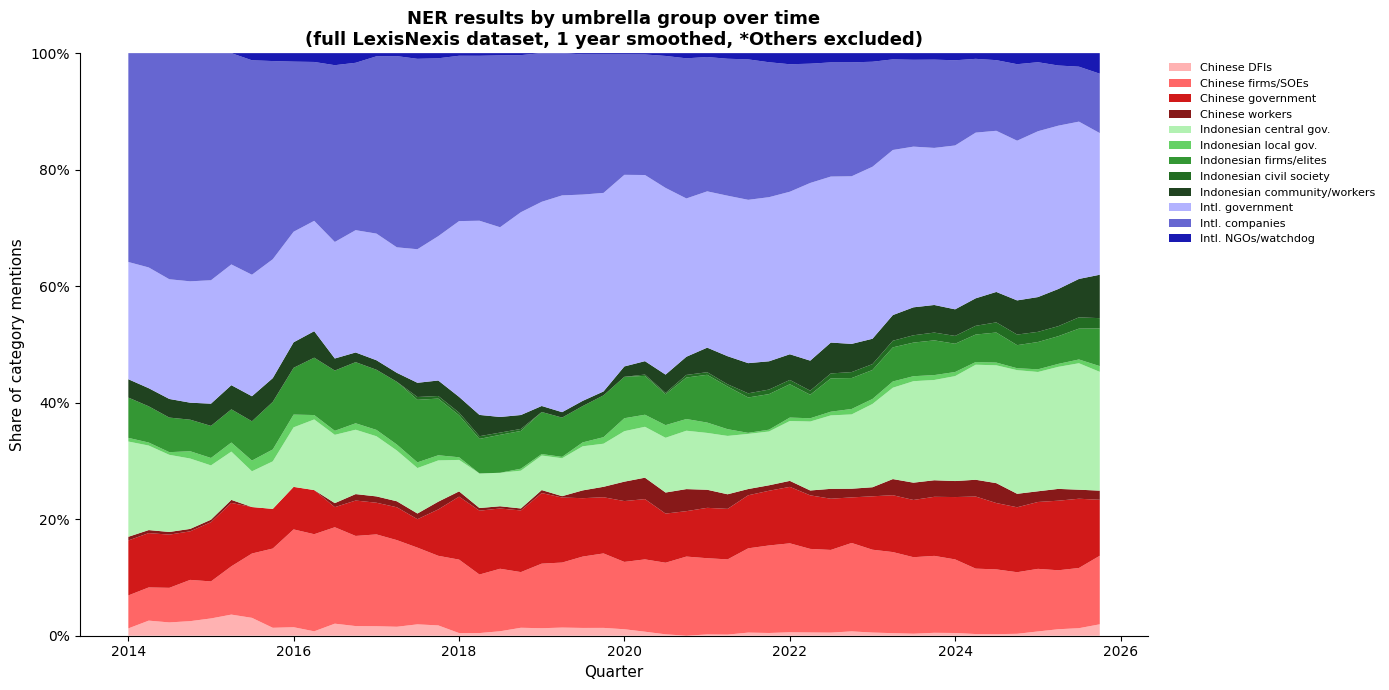

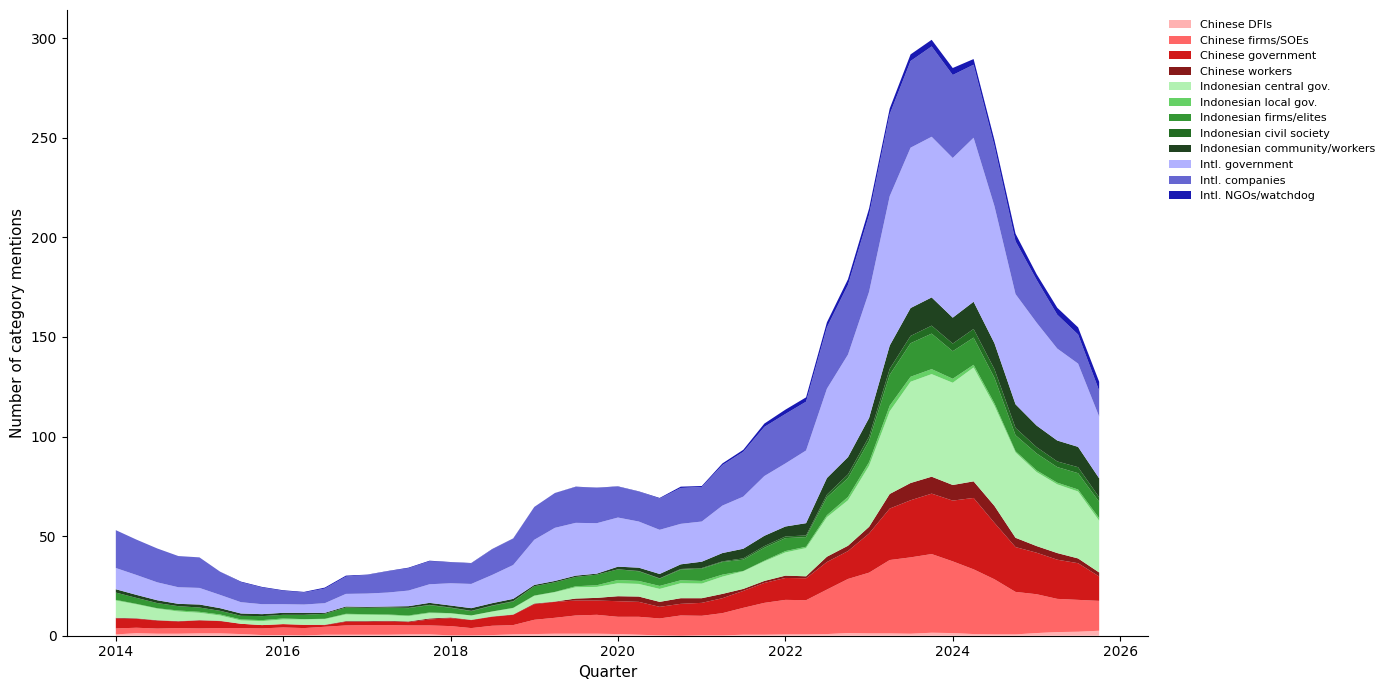

Figure saved: entity_umbrella_over_time_absolute.png


In [30]:

# parse_actors truncates category names that contain parentheses (stops at first ')')
# so match each UMBRELLA key against actual pivot columns tolerantly
def find_col(key, columns):
    if key in columns:
        return key
    # try stripping trailing ')' iteratively
    k = key
    while k.endswith(')'):
        k = k[:-1].rstrip()
        if k in columns:
            return k
    return None

col_map      = {key: find_col(key, pivot.columns) for key in UMBRELLA}
missing      = [k for k, v in col_map.items() if v is None]
if missing:
    print(f'WARNING: no pivot column found for: {missing}')

ordered_keys = sorted(UMBRELLA.keys(), key=lambda c: (UMBRELLA[c][0], UMBRELLA[c][1]))
ordered_cols = [col_map[k] for k in ordered_keys if col_map[k] is not None]
col_colors   = [SHADES[UMBRELLA[k][0]][UMBRELLA[k][1]] for k in ordered_keys if col_map[k] is not None]
col_labels   = [SHORT_LABELS[k]                        for k in ordered_keys if col_map[k] is not None]

pivot_umb    = pivot[ordered_cols].copy()
smoothed_umb = pivot_umb.rolling(window=6, min_periods=1, center=True).mean()
normed_umb   = smoothed_umb.div(smoothed_umb.sum(axis=1), axis=0)
normed_umb.index = normed_umb.index.to_timestamp()

# ── Figure ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 7))

ax.stackplot(normed_umb.index,
             [normed_umb[col] for col in ordered_cols],
             labels=col_labels,
             colors=col_colors,
             alpha=0.9)

ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.set_xlabel('Quarter', fontsize=11)
ax.set_ylabel('Share of category mentions', fontsize=11)
ax.set_title('NER results by umbrella group over time\n'
             '(full LexisNexis dataset, 1 year smoothed, *Others excluded)',
             fontsize=13, fontweight='bold')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8, frameon=False)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()

# Save the relative-share figure before creating the absolute-count figure
FIG_UMB = 'entity_umbrella_over_time.png'
plt.savefig(FIG_UMB, dpi=150, bbox_inches='tight')
plt.show()

# Absolute counts version of the same plot
fig2, ax2 = plt.subplots(figsize=(14, 7))
ax2.stackplot(smoothed_umb.index.to_timestamp(),
              [smoothed_umb[col] for col in ordered_cols],
              labels=col_labels,
              colors=col_colors,
              alpha=0.9)
ax2.set_xlabel('Quarter', fontsize=11)
ax2.set_ylabel('Number of category mentions', fontsize=11)
ax2.set_title('',
              fontsize=13, fontweight='bold')
ax2.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8, frameon=False)
ax2.spines[['top', 'right']].set_visible(False)
ax2.set_ylim(0, smoothed_umb.sum(axis=1).max() * 1.05)
plt.tight_layout()

FIG_UMB_ABS = 'entity_umbrella_over_time_absolute.png'
fig2.savefig(FIG_UMB_ABS, dpi=150, bbox_inches='tight')
plt.show()
print(f'Figure saved: {FIG_UMB_ABS}')

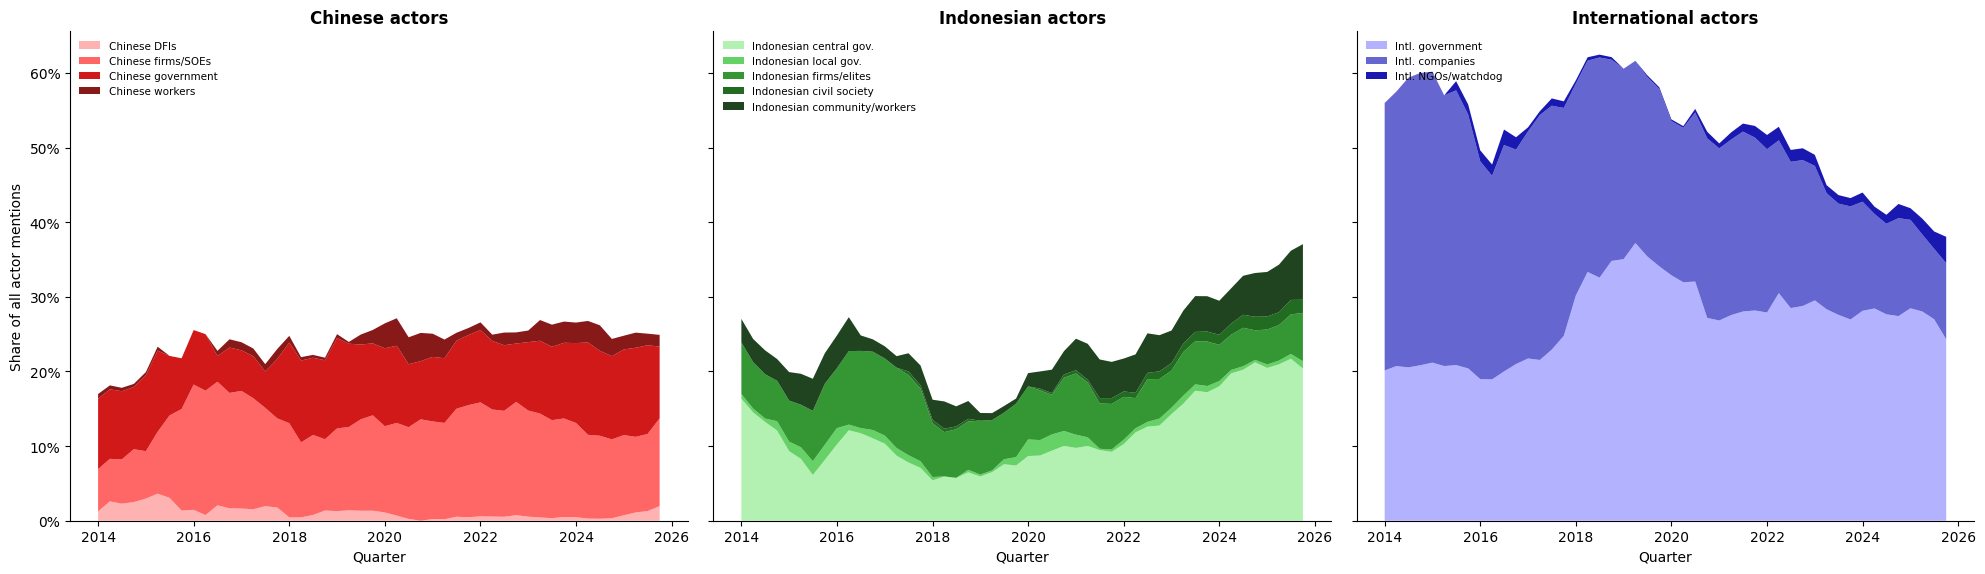

Figure saved: entity_umbrella_triptych.png


In [22]:
# ── Triptych: one panel per umbrella group, shares relative to overall 100% ──

GROUPS = ['Chinese', 'Indonesian', 'International']
GROUP_TITLES = {
    'Chinese':       'Chinese actors',
    'Indonesian':    'Indonesian actors',
    'International': 'International actors',
}

fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

for ax, group in zip(axes, GROUPS):
    g_keys   = [k for k in ordered_keys if UMBRELLA[k][0] == group and col_map[k] is not None]
    g_cols   = [col_map[k] for k in g_keys]
    g_colors = [SHADES[group][UMBRELLA[k][1]] for k in g_keys]
    g_labels = [SHORT_LABELS[k] for k in g_keys]

    # Use the overall-normalised data (normed_umb already sums to 1 across all groups)
    sub = normed_umb[g_cols]

    ax.stackplot(sub.index,
                 [sub[col] for col in g_cols],
                 labels=g_labels,
                 colors=g_colors,
                 alpha=0.9)

    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
    ax.set_title(GROUP_TITLES[group], fontsize=12, fontweight='bold')
    ax.set_xlabel('Quarter', fontsize=10)
    ax.spines[['top', 'right']].set_visible(False)
    ax.legend(loc='upper left', fontsize=7.5, frameon=False)

axes[0].set_ylabel('Share of all actor mentions', fontsize=10)

fig.suptitle('',
             fontsize=13, fontweight='bold')
plt.tight_layout()

FIG_TRIPTYCH = 'entity_umbrella_triptych.png'
plt.savefig(FIG_TRIPTYCH, dpi=150, bbox_inches='tight')
plt.show()
print(f'Figure saved: {FIG_TRIPTYCH}')


In [23]:
# ── Rebuild per-label entity frequencies (full labels, avoids parse_actors truncation) ──
from collections import defaultdict, Counter as _Counter

full_label_ent = defaultdict(_Counter)
for text in ln_full['Text_body']:
    text_lower = str(text).lower()
    for rec in ner_records:
        label = rec['actor_label']
        for ent in rec['named_entities']:
            if ent.lower() in CONTEXT_ONLY:
                continue
            if re.search(make_pattern(ent), text_lower):
                full_label_ent[label][ent] += 1

print('Top-5 entities per subcategory:')
for label in sorted(full_label_ent):
    top5 = full_label_ent[label].most_common(5)
    print(f'  {label}: {[e for e,_ in top5]}')


Top-5 entities per subcategory:
  *Others: ['ecosystem', 'wildlife']
  Chinese DFIs (banks): ['Bank of China', 'Agricultural Bank of China', 'ICBC', 'China Construction Bank', 'Silk Road Fund']
  Chinese firms/SOEs: ['Tsingshan', 'Huayou', 'CATL', 'BYD', 'GEM']
  Chinese government: ['Beijing', 'Xi Jinping', 'President Xi', 'Chinese embassy', 'Chinese authorities']
  Chinese worker: ['Chinese workers', 'Chinese nationals', 'Chinese citizens', 'Chinese migrant workers', 'Chinese personnel']
  Indonesian firms and local elites: ['contractors', 'Indonesia Morowali Industrial Park', 'IMIP', 'Freeport Indonesia', 'Aneka Tambang']
  Indonesian government: central government/president: ['Jakarta', 'Widodo', 'Joko Widodo', 'Prabowo', 'Jokowi']
  Indonesian government: local government (provincial/regional officials): ['provincial government', 'local police', 'The provincial governor', 'mayors', 'regents']
  Indonesian local civil society: ['CELIOS', 'WALHI', 'JATAM', 'Indonesian Forum for the 

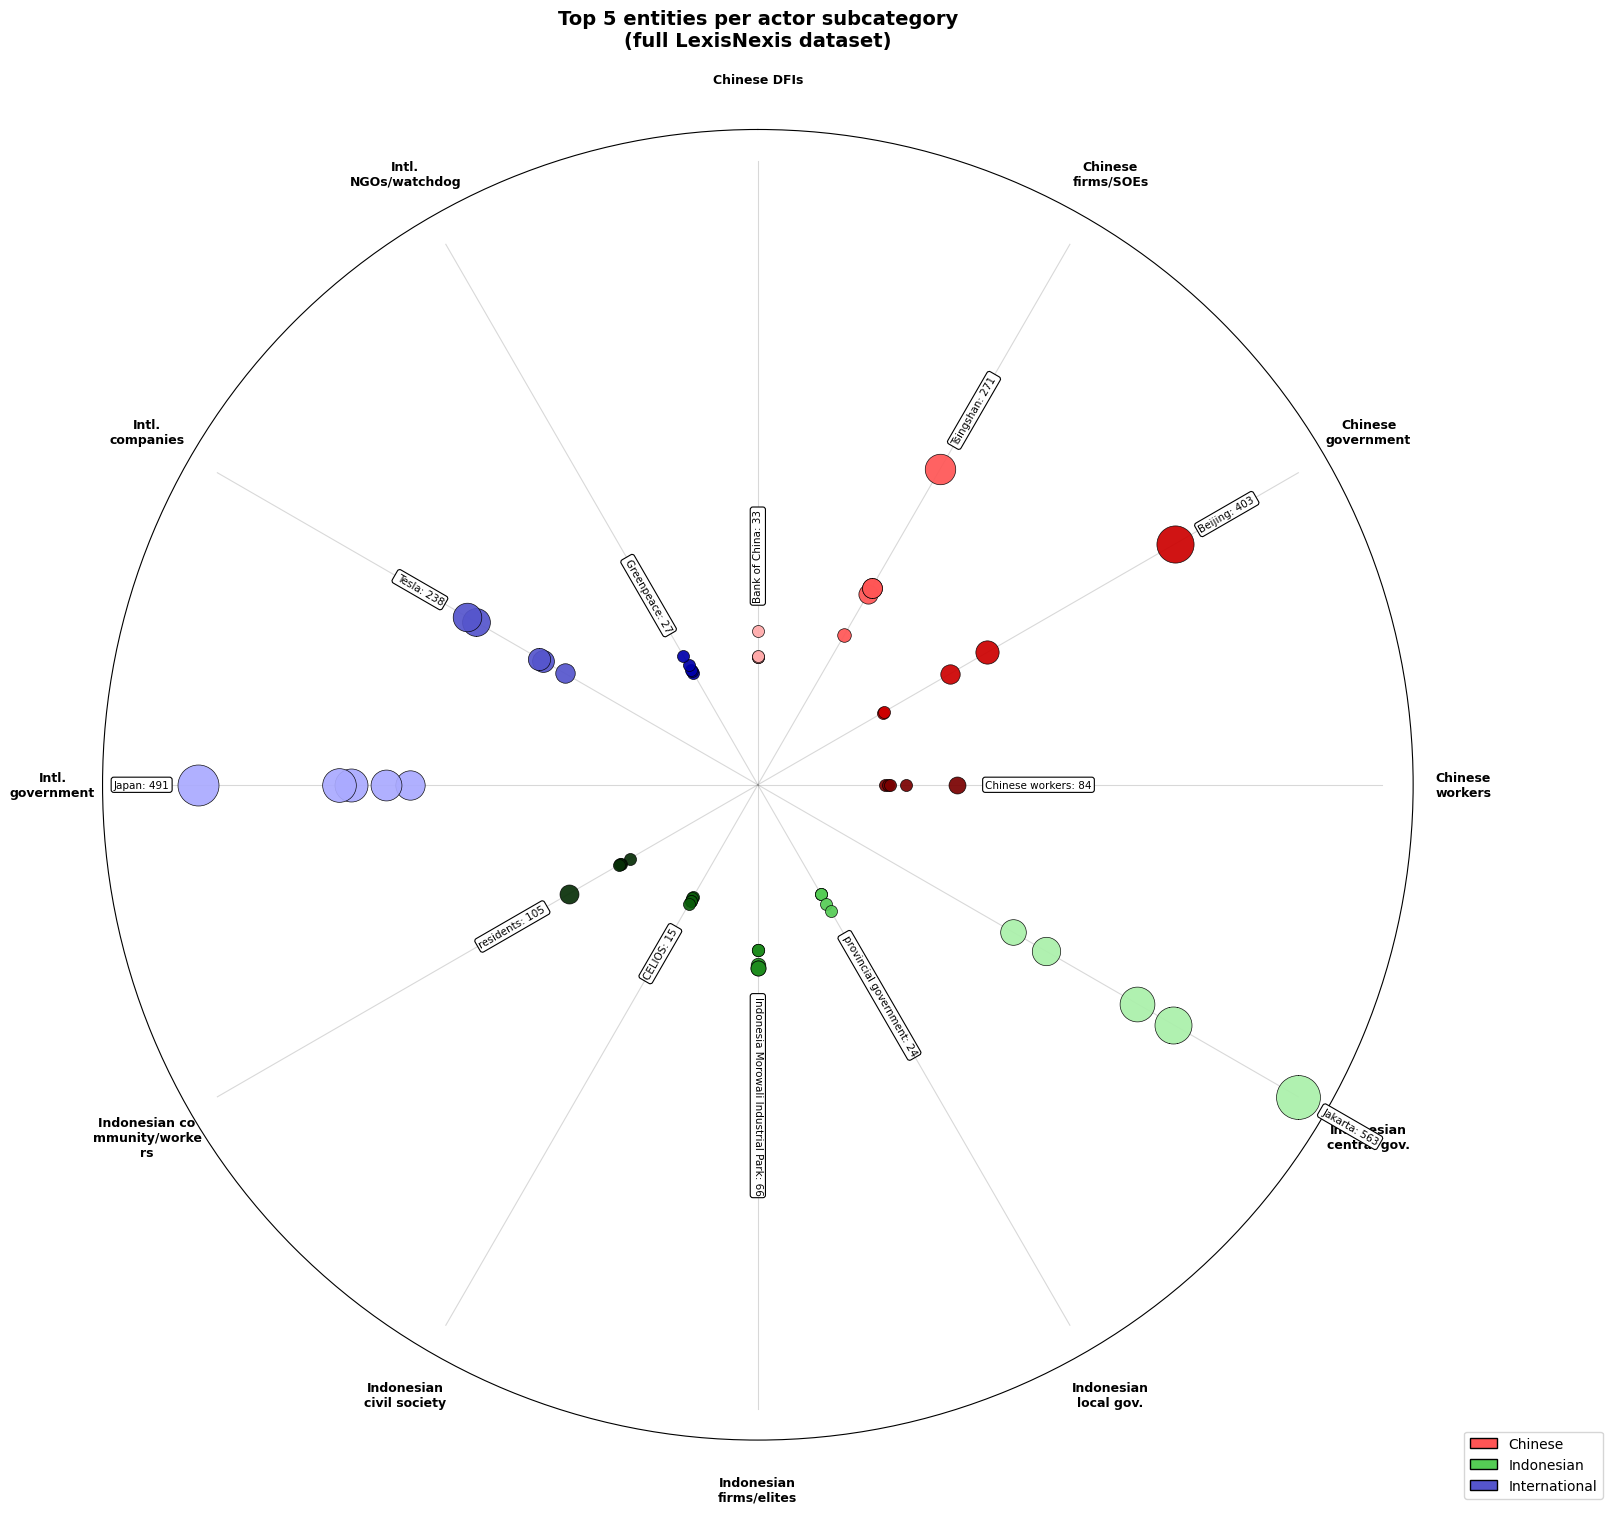

Saved: hive_all_groups.png


In [25]:
# ── Single hive plot: all groups on one circle, colour-coded by group ─────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import textwrap
from collections import Counter

TOP_N = 5
R_MAX = 10
R_MIN = 2

def wrap_label(text, width=13):
    return "\n".join(textwrap.wrap(text.replace("_", " "), width=width))

def readable_rotation(angle):
    """Return (rotation_deg, ha) so text never appears upside-down."""
    rot = np.degrees(np.pi / 2 - angle)
    if rot < -90 or rot > 90:
        return rot + 180, 'right'
    return rot, 'left'

global_max = max(
    count
    for counter in full_label_ent.values()
    for count in counter.values()
) if full_label_ent else 1

all_keys   = [k for k in ordered_keys if col_map.get(k) is not None]
N          = len(all_keys)
theta_axes = np.linspace(0, 2 * np.pi, N, endpoint=False)

fig, ax = plt.subplots(figsize=(16, 16), subplot_kw={'projection': 'polar'})
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)

for angle in theta_axes:
    ax.plot([angle, angle], [0, R_MAX], color='gray', lw=0.8, alpha=0.3)

for i, label in enumerate(all_keys):
    group  = UMBRELLA[label][0]
    idx    = UMBRELLA[label][1]
    color  = SHADES[group][idx]
    angle  = theta_axes[i]

    top5    = full_label_ent.get(label, Counter()).most_common(TOP_N)
    sorted5 = sorted(top5, key=lambda x: x[1])

    for rank, (entity, freq) in enumerate(sorted5):
        r    = R_MIN + (freq / global_max) * (R_MAX - R_MIN)
        size = max(75, 1000 * (freq / global_max))
        ax.scatter(angle, r, s=size, color=color,
                   edgecolors='black', linewidth=0.5, alpha=0.92, zorder=5)

        if rank == len(sorted5) - 1:
            rot, ha = readable_rotation(angle)
            ax.text(angle, r + 0.45, f'{entity}: {freq}',
                    ha=ha, va='center', fontsize=7.5,
                    color='black', rotation=rot, rotation_mode='anchor',
                    zorder=10,
                    bbox=dict(boxstyle='round,pad=0.25', facecolor='white',
                              edgecolor='black', linewidth=0.8))

    ax.text(angle, R_MAX + 1.3,
            wrap_label(SHORT_LABELS.get(label, label)),
            ha='center', va='center', fontsize=9, fontweight='bold')

legend_handles = [
    mpatches.Patch(facecolor=SHADES[g][1], edgecolor='black', label=g)
    for g in ['Chinese', 'Indonesian', 'International']
]
ax.legend(handles=legend_handles, loc='lower right',
          bbox_to_anchor=(1.15, -0.05), fontsize=10, frameon=True)

ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
ax.set_title('Top 5 entities per actor subcategory\n(full LexisNexis dataset)',
             fontsize=14, fontweight='bold', pad=60)

plt.tight_layout()
FIG_HIVE = 'hive_all_groups.png'
plt.savefig(FIG_HIVE, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {FIG_HIVE}')


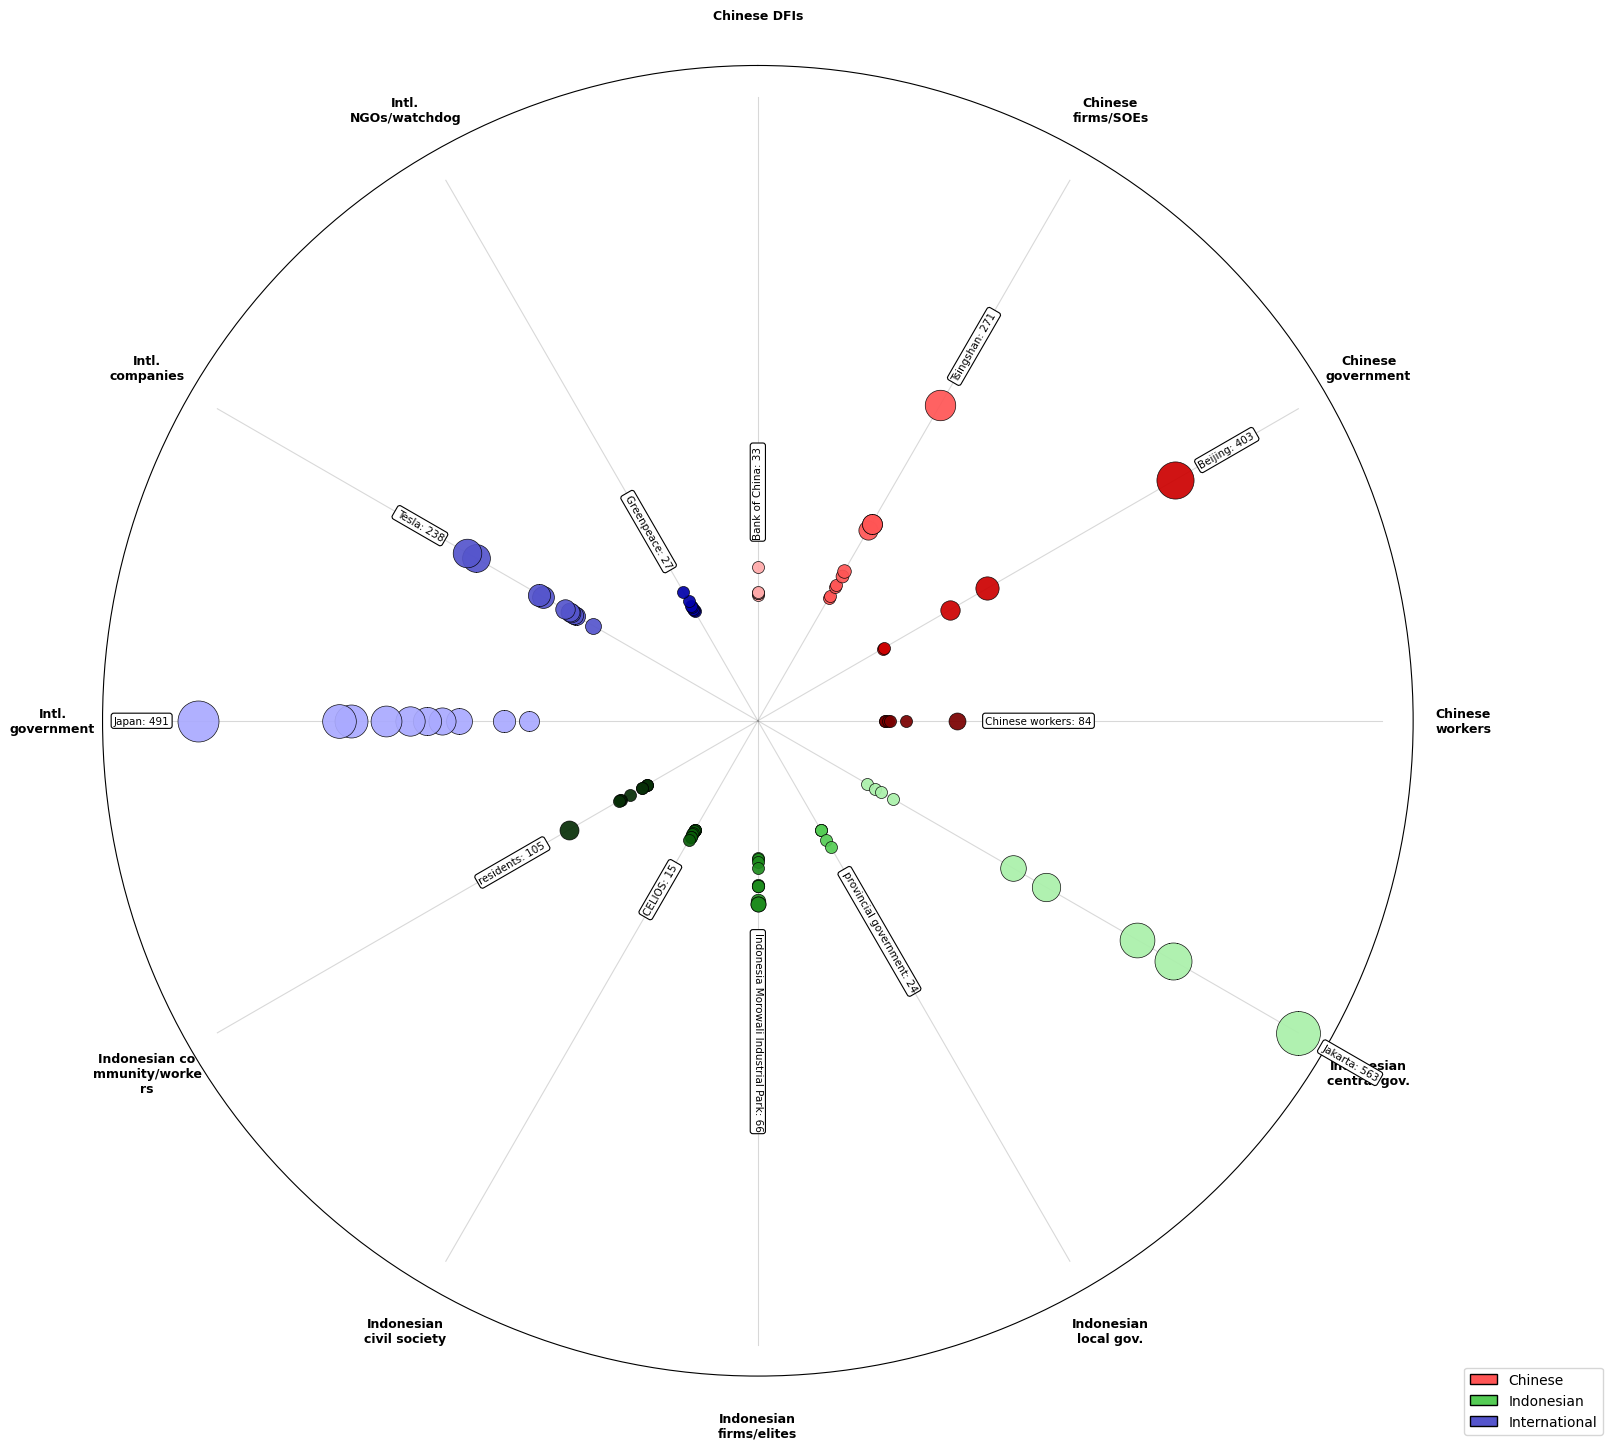

Saved: C:\Users\charlott\Dropbox (Personal)\Paper_Indonesia_Nickel\ln_training\hive_all_groups_top10.png


In [33]:
# ── Same hive plot, top 10 entities per subcategory ───────────────────────────
fig, ax = plt.subplots(figsize=(16, 16), subplot_kw={'projection': 'polar'})
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)

for angle in theta_axes:
    ax.plot([angle, angle], [0, R_MAX], color='gray', lw=0.8, alpha=0.3)

for i, label in enumerate(all_keys):
    group  = UMBRELLA[label][0]
    idx    = UMBRELLA[label][1]
    color  = SHADES[group][idx]
    angle  = theta_axes[i]

    top10   = full_label_ent.get(label, Counter()).most_common(10)
    sorted10 = sorted(top10, key=lambda x: x[1])

    for rank, (entity, freq) in enumerate(sorted10):
        r    = R_MIN + (freq / global_max) * (R_MAX - R_MIN)
        size = max(75, 1000 * (freq / global_max))
        ax.scatter(angle, r, s=size, color=color,
                   edgecolors='black', linewidth=0.5, alpha=0.92, zorder=5)

        if rank == len(sorted10) - 1:
            rot, ha = readable_rotation(angle)
            ax.text(angle, r + 0.45, f'{entity}: {freq}',
                    ha=ha, va='center', fontsize=7.5,
                    color='black', rotation=rot, rotation_mode='anchor',
                    zorder=10,
                    bbox=dict(boxstyle='round,pad=0.25', facecolor='white',
                              edgecolor='black', linewidth=0.8))

    ax.text(angle, R_MAX + 1.3,
            wrap_label(SHORT_LABELS.get(label, label)),
            ha='center', va='center', fontsize=9, fontweight='bold')

legend_handles = [
    mpatches.Patch(facecolor=SHADES[g][1], edgecolor='black', label=g)
    for g in ['Chinese', 'Indonesian', 'International']
]
ax.legend(handles=legend_handles, loc='lower right',
          bbox_to_anchor=(1.15, -0.05), fontsize=10, frameon=True)

ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
ax.set_title('',
             fontsize=14, fontweight='bold', pad=60)

plt.tight_layout()
FIG_HIVE10 = r'C:\Users\charlott\Dropbox (Personal)\Paper_Indonesia_Nickel\ln_training\hive_all_groups_top10.png'
plt.savefig(FIG_HIVE10, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {FIG_HIVE10}')


---
## GLiNER: surfacing unknown entities not yet in the codebook

Runs a zero-shot NER model (GLiNER) with labels tailored to the 12 actor categories.  
Any entity it finds that is **not already in `ner_actor_codebook.json`** is a candidate for codebook expansion.

In [ ]:
# -- Load NER model ----------------------------------------------------------
# Workaround for protobuf/sentencepiece version conflict on Windows:
# Must be set before any imports that touch sentencepiece/protobuf.
import os
os.environ["PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION"] = "python"

USE_GLINER = True   # set False to fall back to HuggingFace pipeline

if USE_GLINER:
    from gliner import GLiNER
    print("Loading GLiNER...")
    ner_backend = GLiNER.from_pretrained("urchade/gliner_mediumv2.1", max_length=512)
    print("GLiNER ready.")
else:
    from transformers import pipeline as hf_pipeline
    print("Loading HuggingFace NER pipeline (dslim/bert-base-NER)...")
    ner_backend = hf_pipeline("ner",
                               model="dslim/bert-base-NER",
                               aggregation_strategy="simple",
                               device=-1)
    print("HuggingFace NER pipeline ready.")


In [32]:
# -- Run GLiNER on a random sample of 1000 articles --------------------------
import random
from collections import defaultdict, Counter

GLINER_LABEL_MAP = {
    "Chinese company or SOE":                          "Chinese firms/SOEs",
    "Chinese bank or development finance institution": "Chinese DFIs (banks)",
    "Chinese government official or body":             "Chinese government",
    "Chinese worker or laborer":                       "Chinese worker",
    "Indonesian president or central government":      "Indonesian government: central government/president",
    "Indonesian provincial or regional official":      "Indonesian government: local government (provincial/regional officials)",
    "Indonesian company or business elite":            "Indonesian firms and local elites",
    "Indonesian civil society organization":           "Indonesian local civil society",
    "Indonesian local community or worker":            "Indonesian local community & workers",
    "international government or intergovernmental":   "International government (EU/US/others)",
    "international company or multinational":          "International companies",
    "international NGO or watchdog":                   "International NGOs/watchdog",
}
gliner_labels = list(GLINER_LABEL_MAP.keys())

MAX_WORDS   = 300
THRESHOLD   = 0.40
BATCH_SIZE  = 32
N_SAMPLE    = 1000
RANDOM_SEED = 42

all_texts = (
    ln_full["Text_body"]
    .fillna("")
    .apply(lambda t: " ".join(str(t).split()[:MAX_WORDS]))
    .tolist()
)
random.seed(RANDOM_SEED)
texts = random.sample(all_texts, min(N_SAMPLE, len(all_texts)))

gliner_counts = defaultdict(Counter)
total = len(texts)
print(f"Running GLiNER on {total:,} randomly sampled articles in batches of {BATCH_SIZE}...")

for start in range(0, total, BATCH_SIZE):
    batch = texts[start : start + BATCH_SIZE]
    try:
        results = ner_backend.batch_predict_entities(batch, gliner_labels, threshold=THRESHOLD)
    except AttributeError:
        results = [ner_backend.predict_entities(t, gliner_labels, threshold=THRESHOLD) for t in batch]
    for result in results:
        for ent in result:
            cat = GLINER_LABEL_MAP[ent["label"]]
            gliner_counts[cat][ent["text"].strip()] += 1
    if start % (BATCH_SIZE * 10) == 0:
        print(f"  {min(start + BATCH_SIZE, total):>6,} / {total:,}")

print("Done.")


Running GLiNER on 1,000 randomly sampled articles in batches of 32...


NameError: name 'ner_backend' is not defined

In [31]:
# ── Diff GLiNER results against codebook → new entity candidates ──────────────

# Build flat set of known entities per category (lowercased for matching)
known_per_cat = defaultdict(set)
for rec in ner_records:
    for ent in rec['named_entities']:
        known_per_cat[rec['actor_label']].add(ent.lower().strip())

rows = []
for cat, counter in gliner_counts.items():
    known = known_per_cat.get(cat, set())
    for entity, freq in counter.most_common():
        in_cb = entity.lower().strip() in known
        rows.append({
            'actor_category': cat,
            'entity':         entity,
            'frequency':      freq,
            'in_codebook':    in_cb,
        })

gliner_df   = pd.DataFrame(rows).sort_values(['actor_category', 'frequency'],
                                              ascending=[True, False])
new_ents    = gliner_df[~gliner_df['in_codebook']].reset_index(drop=True)

print(f'GLiNER total entity mentions   : {gliner_df["frequency"].sum():,}')
print(f'Already in codebook            : {gliner_df["in_codebook"].sum():,}')
print(f'New candidate entities         : {len(new_ents):,}')
print()
print('=== Top 10 new entities per category ===')
for cat in sorted(new_ents['actor_category'].unique()):
    top = new_ents[new_ents['actor_category'] == cat].head(10)
    print(f'\n  [{cat}]')
    for _, row in top.iterrows():
        print(f'    {row["entity"]:<45}  n={row["frequency"]}')

GLINER_OUT = r'C:\Users\charlott\Dropbox (Personal)\Paper_Indonesia_Nickel\ln_training\gliner_new_entities.xlsx'
new_ents.to_excel(GLINER_OUT, index=False)
print(f'\nFull list saved → {GLINER_OUT}')


NameError: name 'gliner_counts' is not defined